# 🔮 PriceOracle — Multi-LLM Product Price Benchmarking System

**Milestone 6 | LLM Evaluation Sprint**

---

## What This Notebook Does

PriceOracle benchmarks multiple Large Language Models (LLMs) on their ability to predict product retail prices.

**Models compared:**
- 🔵 Google Gemini 2.5 Flash
- 🟠 Meta Llama 3.3 70B (via Groq)
- 🟢 OpenAI GPT-4o-mini *(optional)*

**Metrics used:**
- MAE — Mean Absolute Error (average dollar error)
- MAPE — Mean Absolute Percentage Error (scale-independent, primary metric)
- RMSE — Root Mean Squared Error (penalizes large mistakes)

**Dataset:** 20 real consumer electronics products with verified ground truth prices sourced from US retail markets.

---

## ⚙️ Before You Start — API Keys Needed

You will need **free API keys** from:
1. **Google AI Studio** → https://aistudio.google.com/app/apikey  (free tier available)
2. **Groq Console** → https://console.groq.com/keys  (free tier, very fast)
3. **OpenAI** → https://platform.openai.com/api-keys  *(optional — skip if you want)*

You will enter your keys in **Cell 3**.

---

## 📋 Notebook Flow

```
Cell 1  → Install packages
Cell 2  → Import libraries
Cell 3  → Enter API keys
Cell 4  → Load dataset
Cell 5  → Define prompt builder
Cell 6  → Define response parser
Cell 7  → Define API callers (Gemini, Groq, GPT)
Cell 8  → Define metric functions
Cell 9  → Run full evaluation pipeline
Cell 10 → Compute metrics & display leaderboard
Cell 11 → Visualizations (bar charts)
Cell 12 → Per-product breakdown table
Cell 13 → Save results to CSV
```

> **Run each cell in order. Do not skip any cell.**

## Cell 1 — Install Required Packages

This installs all Python packages needed for the project.

- `google-generativeai` → Gemini API SDK
- `groq` → Groq API SDK (for Llama)
- `openai` → OpenAI SDK (for GPT-4o-mini, optional)
- `pandas`, `numpy`, `scikit-learn` → data handling and metrics
- `matplotlib`, `seaborn` → visualization

**Expected output:** Several lines of `Successfully installed ...`  
**If you see errors:** Re-run this cell once more — sometimes package resolution takes two runs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Cell 1: Install packages ─────────────────────────────────────
# Run this cell first. It may take 30-60 seconds.

!pip install google-generativeai groq openai pandas numpy scikit-learn matplotlib seaborn --quiet

print("✅ All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 5.8 MB/s eta 0:00:00
✅ All packages installed successfully.


## Cell 2 — Import Libraries

Importing all required libraries into the Python environment.

**Expected output:** `✅ All imports successful.`  
**If you see ImportError:** Go back and re-run Cell 1.

In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────

import os
import re
import json
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

# LLM APIs
import google.generativeai as genai
from groq import Groq

# OpenAI (optional — only imported if GPT is enabled later)
try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True
except ImportError:
    OPENAI_AVAILABLE = False

print("✅ All imports successful.")
print(f"   pandas  version: {pd.__version__}")
print(f"   numpy   version: {np.__version__}")

✅ All imports successful.
   pandas  version: 2.2.2
   numpy   version: 2.0.2


## Cell 3 — Configure API Keys

**You MUST enter your own API keys here before proceeding.**

Replace the placeholder strings with your real keys:
- `GEMINI_API_KEY` → from https://aistudio.google.com/app/apikey
- `GROQ_API_KEY` → from https://console.groq.com/keys
- `OPENAI_API_KEY` → from https://platform.openai.com/api-keys *(leave as empty string `""` to skip GPT)*

**Expected output:** `✅ API keys configured.` followed by which models are active.

In [ ]:
# ── Cell 3: API Key Configuration ────────────────────────────────
# IMPORTANT: Replace the placeholder strings with your actual API keys.
# Never share this notebook with your keys filled in.

# ─── REQUIRED ────────────────────────────────────────────────────
GEMINI_API_KEY = ""      # Get from: aistudio.google.com
GROQ_API_KEY   = ""        # Get from: console.groq.com

# ─── OPTIONAL (leave as empty string "" to skip GPT-4o-mini) ─────
OPENAI_API_KEY = ""                               # Get from: platform.openai.com

# ─── Validate ────────────────────────────────────────────────────
USE_GEMINI = bool(GEMINI_API_KEY and GEMINI_API_KEY != "YOUR_GEMINI_API_KEY_HERE")
USE_GROQ   = bool(GROQ_API_KEY   and GROQ_API_KEY   != "YOUR_GROQ_API_KEY_HERE")
USE_GPT    = bool(OPENAI_API_KEY and OPENAI_AVAILABLE)

print("✅ API keys configured.")
print(f"   Gemini 2.5 Flash : {'✅ ACTIVE' if USE_GEMINI else '❌ NOT SET — skipped'}")
print(f"   Llama 3.3 70B    : {'✅ ACTIVE' if USE_GROQ   else '❌ NOT SET — skipped'}")
print(f"   GPT-4o-mini      : {'✅ ACTIVE' if USE_GPT    else '⚪ OPTIONAL — skipped'}")

if not USE_GEMINI and not USE_GROQ:
    print("\n⚠️  WARNING: Both required API keys are missing.")
    print("   Please enter at least one key to run the evaluation.")

✅ API keys configured.
   Gemini 2.5 Flash : ✅ ACTIVE
   Llama 3.3 70B    : ✅ ACTIVE
   GPT-4o-mini      : ⚪ OPTIONAL — skipped


## Cell 4 — Load Dataset

This cell creates the evaluation dataset directly in the notebook — no external file download needed.

The dataset contains **20 real consumer electronics products** with:
- Product name, category, brand
- Key features (relevant for price estimation)
- Ground truth price (verified from US retail market, 2024-2025)

**Expected output:** A table showing all 20 products with their details.

In [ ]:
# ── Cell 4: Dataset ───────────────────────────────────────────────
# 20 real consumer electronics products with ground truth prices.
# Prices represent typical US retail market values (2024-2025).

products_data = [
    # Televisions
    {"name": "Sony BRAVIA 55-inch 4K LED TV",      "category": "Television",  "brand": "Sony",     "features": "4K UHD, Smart TV Android, HDR10, 2 HDMI ports, 60Hz, new 2024",    "ground_truth_price": 748.00},
    {"name": "Samsung 65-inch QLED 4K TV",          "category": "Television",  "brand": "Samsung",  "features": "4K QLED, Smart TV Tizen, 120Hz, 4 HDMI, Quantum HDR, new 2024",    "ground_truth_price": 1097.99},
    {"name": "LG 43-inch 4K UHD Smart TV",          "category": "Television",  "brand": "LG",       "features": "4K UHD, WebOS Smart TV, 60Hz, HDR, 2 HDMI ports",                  "ground_truth_price": 296.99},
    {"name": "TCL 32-inch HD Roku Smart TV",         "category": "Television",  "brand": "TCL",      "features": "HD 720p, Roku built-in, 2 HDMI, budget tier",                      "ground_truth_price": 129.99},
    {"name": "Hisense 50-inch 4K ULED TV",           "category": "Television",  "brand": "Hisense",  "features": "4K ULED, Google TV, Dolby Vision, 60Hz, 3 HDMI",                   "ground_truth_price": 329.99},
    # Laptops
    {"name": "Apple MacBook Air 13-inch M3",         "category": "Laptop",      "brand": "Apple",    "features": "M3 chip, 8GB RAM, 256GB SSD, 13.6-inch Retina, macOS, 2024",       "ground_truth_price": 1099.00},
    {"name": "Dell XPS 15 Intel Core i7",            "category": "Laptop",      "brand": "Dell",     "features": "Intel Core i7-13700H, 16GB RAM, 512GB SSD, 15.6-inch OLED, Win11", "ground_truth_price": 1599.99},
    {"name": "HP Pavilion 15 AMD Ryzen 5",           "category": "Laptop",      "brand": "HP",       "features": "AMD Ryzen 5 7530U, 8GB RAM, 256GB SSD, 15.6-inch FHD, Win11",      "ground_truth_price": 449.99},
    {"name": "Lenovo IdeaPad 3 Intel Core i3",       "category": "Laptop",      "brand": "Lenovo",   "features": "Intel Core i3-1215U, 8GB RAM, 256GB SSD, 15.6-inch FHD, Win11",   "ground_truth_price": 329.99},
    {"name": "Microsoft Surface Pro 9",              "category": "Laptop",      "brand": "Microsoft","features": "Intel Core i5, 8GB RAM, 256GB SSD, 13-inch touchscreen, Win11 Pro", "ground_truth_price": 999.99},
    # Smartphones
    {"name": "Apple iPhone 15 128GB",                "category": "Smartphone",  "brand": "Apple",    "features": "A16 Bionic, 6.1-inch OLED, 48MP camera, 5G, iOS 17",               "ground_truth_price": 699.00},
    {"name": "Samsung Galaxy S24 256GB",             "category": "Smartphone",  "brand": "Samsung",  "features": "Snapdragon 8 Gen 3, 6.2-inch AMOLED, 50MP, 5G, Android 14",       "ground_truth_price": 799.99},
    {"name": "Google Pixel 8 128GB",                 "category": "Smartphone",  "brand": "Google",   "features": "Google Tensor G3, 6.2-inch OLED, 50MP, 5G, Android 14",           "ground_truth_price": 599.00},
    {"name": "OnePlus 12 256GB",                     "category": "Smartphone",  "brand": "OnePlus",  "features": "Snapdragon 8 Gen 3, 6.82-inch AMOLED, 50MP Hasselblad, 5G",       "ground_truth_price": 699.99},
    {"name": "Motorola Moto G Power 5G 128GB",       "category": "Smartphone",  "brand": "Motorola", "features": "Snapdragon 4 Gen 1, 6.5-inch LCD, 50MP, 5G, 5000mAh budget",      "ground_truth_price": 199.99},
    # Headphones & Audio
    {"name": "Sony WH-1000XM5 Wireless ANC",         "category": "Headphones",  "brand": "Sony",     "features": "Over-ear, ANC, 30hr battery, Bluetooth 5.2, Hi-Res Audio",          "ground_truth_price": 279.99},
    {"name": "Apple AirPods Pro 2nd Generation",     "category": "Headphones",  "brand": "Apple",    "features": "In-ear, ANC, Adaptive Transparency, H2 chip, USB-C",               "ground_truth_price": 189.00},
    {"name": "Bose QuietComfort 45",                  "category": "Headphones",  "brand": "Bose",     "features": "Over-ear, ANC, 24hr battery, Bluetooth 5.1, folding design",       "ground_truth_price": 249.00},
    {"name": "JBL Tune 770NC",                        "category": "Headphones",  "brand": "JBL",      "features": "Over-ear, ANC, 70hr battery, Bluetooth 5.3, budget-mid tier",     "ground_truth_price": 79.95},
    {"name": "Jabra Evolve2 65 Business Headset",    "category": "Headphones",  "brand": "Jabra",    "features": "Over-ear, ANC, 37hr battery, Bluetooth 5.0, business UC certified", "ground_truth_price": 249.99},
]

df = pd.DataFrame(products_data)

# Display with formatting
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 25)
print(f"✅ Dataset loaded: {len(df)} products across {df['category'].nunique()} categories")
print(f"   Categories: {list(df['category'].unique())}")
print(f"   Price range: ${df['ground_truth_price'].min():.2f} – ${df['ground_truth_price'].max():.2f}")
print()
df[['name', 'category', 'brand', 'ground_truth_price']]

✅ Dataset loaded: 20 products across 4 categories
   Categories: ['Television', 'Laptop', 'Smartphone', 'Headphones']
   Price range: $79.95 – $1599.99



,name,category,brand,ground_truth_price
0,Sony BRAVIA 55-inch 4K LED TV,Television,Sony,748.00
1,Samsung 65-inch QLED 4K TV,Television,Samsung,1097.99
2,LG 43-inch 4K UHD Smart TV,Television,LG,296.99
3,TCL 32-inch HD Roku Smart TV,Television,TCL,129.99
4,Hisense 50-inch 4K ULED TV,Television,Hisense,329.99
5,Apple MacBook Air 13-inch M3,Laptop,Apple,1099.00
6,Dell XPS 15 Intel Core i7,Laptop,Dell,1599.99
7,HP Pavilion 15 AMD Ryzen 5,Laptop,HP,449.99
8,Lenovo IdeaPad 3 Intel Core i3,Laptop,Lenovo,329.99
9,Microsoft Surface Pro 9,Laptop,Microsoft,999.99


## Cell 5 — Prompt Builder

This function constructs the prompt sent to each LLM for price prediction.

**Design principles:**
- Explicit JSON output format instruction
- No ambiguity in what is expected
- Product features injected cleanly

**Expected output:** A formatted prompt string printed as a test.

In [ ]:
def build_price_prompt(product_info: dict) -> str:
    """
    Build a structured prompt for price prediction.
    Instructs the LLM to return ONLY a JSON object with the price.

    Args:
        product_info (dict): product details — name, category, brand, features

    Returns:
        str: complete prompt string ready to send to any LLM
    """
    # Note the double braces {{ }} used below to escape the JSON example
    prompt = f"""You are a product pricing expert with deep knowledge of US consumer electronics retail markets.

Product Details:
- Name: {product_info.get('name', 'Unknown Product')}
- Category: {product_info.get('category', 'Electronics')}
- Brand: {product_info.get('brand', 'Unknown')}
- Key Features: {product_info.get('features', 'Standard')}
- Condition: New (retail box)
- Market: United States

Task: Estimate the typical US retail price of this product.

STRICT INSTRUCTIONS:
- Output MUST be valid JSON only
- Do NOT include any text before or after JSON
- Do NOT say "Here is the JSON"
- Do NOT explain anything
- Format EXACTLY like this: {{"price": 749.99}}
- The response must be directly parsable using json.loads()

Output:"""

    return prompt


# ─── Test the prompt builder ──────────────────────────────────────
test_product = {
    "name": "Sony BRAVIA 55-inch 4K LED TV",
    "category": "Television",
    "brand": "Sony",
    "features": "4K UHD, Smart TV Android, HDR10, 2 HDMI ports, 60Hz, new 2024"
}

sample_prompt = build_price_prompt(test_product)
print("✅ Prompt builder working. Sample prompt:")
print("─" * 60)
print(sample_prompt)
print("─" * 60)


✅ Prompt builder working. Sample prompt:
────────────────────────────────────────────────────────────
You are a product pricing expert with deep knowledge of US consumer electronics retail markets.

Product Details:
- Name: Sony BRAVIA 55-inch 4K LED TV
- Category: Television
- Brand: Sony
- Key Features: 4K UHD, Smart TV Android, HDR10, 2 HDMI ports, 60Hz, new 2024
- Condition: New (retail box)
- Market: United States

Task: Estimate the typical US retail price of this product.

STRICT INSTRUCTIONS:
- Output MUST be valid JSON only
- Do NOT include any text before or after JSON
- Do NOT say "Here is the JSON"
- Do NOT explain anything
- Format EXACTLY like this: {"price": 749.99}
- The response must be directly parsable using json.loads()

Output:
────────────────────────────────────────────────────────────


## Cell 6 — Response Parser

LLMs don't always return clean JSON. This parser handles:
1. Clean JSON → direct `json.loads()`
2. JSON wrapped in markdown ` ```json ``` ` blocks → strip then parse
3. Text responses with a number → regex extraction
4. Complete failure → returns `None`

**Expected output:** Test results showing all 6 edge cases parsed correctly.

In [ ]:
# ── Cell 6: Response Parser ───────────────────────────────────────

def parse_price_response(raw_response: str) -> float | None:
    """
    Parse an LLM's raw string response and extract the price as a float.

    Tries in this order:
      1. JSON parsing (primary)
      2. Regex number extraction (fallback)
      3. Returns None if all methods fail

    Args:
        raw_response (str): raw string from any LLM

    Returns:
        float | None: parsed price, or None on failure
    """
    if not raw_response or not isinstance(raw_response, str):
        return None

    # ── Step 1: Clean markdown code fences ────────────────────────
    cleaned = raw_response.strip()
    cleaned = re.sub(r'```(?:json)?\s*', '', cleaned)  # remove ```json or ```
    cleaned = re.sub(r'```\s*', '', cleaned)            # remove closing ```
    cleaned = cleaned.strip()

    # ── Step 2: JSON parsing (primary method) ─────────────────────
    try:
        parsed = json.loads(cleaned)

        if isinstance(parsed, dict):
            # Try common key names the model might use
            for key in ["price", "Price", "PRICE", "cost", "value", "estimated_price"]:
                if key in parsed:
                    raw_val = parsed[key]
                    # Handle if value itself is a string like "$749.99"
                    if isinstance(raw_val, str):
                        raw_val = re.sub(r'[^0-9.]', '', raw_val)
                    price = float(raw_val)
                    if 1.0 <= price <= 99999.0:  # sanity range
                        return round(price, 2)

        elif isinstance(parsed, (int, float)):
            price = float(parsed)
            if 1.0 <= price <= 99999.0:
                return round(price, 2)

    except (json.JSONDecodeError, ValueError, TypeError, KeyError):
        pass  # fall through to regex

    # ── Step 3: Regex fallback ─────────────────────────────────────
    # Look for price-like numbers: optional $, digits, optional decimal
    numbers = re.findall(r'\$?\s*(\d{1,6}(?:\.\d{1,2})?)', cleaned)

    for num_str in numbers:
        try:
            price = float(num_str)
            if 1.0 <= price <= 99999.0:
                return round(price, 2)
        except ValueError:
            continue

    # ── Step 4: Complete failure ───────────────────────────────────
    return None


# ─── Test the parser ──────────────────────────────────────────────
test_cases = [
    ('{"price": 749.99}',                         749.99),
    ('{"Price": 750}',                             750.00),
    ('```json\n{"price": 748.00}\n```',            748.00),
    ('The price is approximately $750.00',         750.00),
    ('{"price": "$749.99"}',                       749.99),
    ('I cannot determine the price.',              None),
]

print("✅ Parser test results:")
all_pass = True
for raw, expected in test_cases:
    result = parse_price_response(raw)
    status = "✅" if result == expected else "❌"
    if result != expected:
        all_pass = False
    print(f"  {status}  Input: {raw[:45]:<45}  Expected: {str(expected):<8}  Got: {result}")

print()
print(f"{'✅ All tests passed!' if all_pass else '⚠️  Some tests failed — check parser logic'}")

✅ Parser test results:
  ✅  Input: {"price": 749.99}                              Expected: 749.99    Got: 749.99
  ✅  Input: {"Price": 750}                                 Expected: 750.0     Got: 750.0
  ✅  Input: ```json
{"price": 748.00}
```                  Expected: 748.0     Got: 748.0
  ✅  Input: The price is approximately $750.00             Expected: 750.0     Got: 750.0
  ✅  Input: {"price": "$749.99"}                           Expected: 749.99    Got: 749.99
  ✅  Input: I cannot determine the price.                  Expected: None      Got: None

✅ All tests passed!


In [ ]:
import google.generativeai as genai

# Configure API key
genai.configure(api_key=GEMINI_API_KEY)

print("🔍 Fetching available Gemini models...\n")

try:
    models = genai.list_models()

    available = []
    for m in models:
        # Only keep models that support text generation
        if "generateContent" in m.supported_generation_methods:
            available.append(m.name)

    if not available:
        print("❌ No usable models found for generateContent")
    else:
        print("✅ Available models:\n")
        for name in available:
            print(f"   - {name}")

except Exception as e:
    print("❌ Error fetching models:")
    print(e)

🔍 Fetching available Gemini models...

✅ Available models:

   - models/gemini-2.5-flash
   - models/gemini-2.5-pro
   - models/gemini-2.0-flash
   - models/gemini-2.0-flash-001
   - models/gemini-2.0-flash-lite-001
   - models/gemini-2.0-flash-lite
   - models/gemini-2.5-flash-preview-tts
   - models/gemini-2.5-pro-preview-tts
   - models/gemma-3-1b-it
   - models/gemma-3-4b-it
   - models/gemma-3-12b-it
   - models/gemma-3-27b-it
   - models/gemma-3n-e4b-it
   - models/gemma-3n-e2b-it
   - models/gemini-flash-latest
   - models/gemini-flash-lite-latest
   - models/gemini-pro-latest
   - models/gemini-2.5-flash-lite
   - models/gemini-2.5-flash-image
   - models/gemini-2.5-flash-lite-preview-09-2025
   - models/gemini-3-pro-preview
   - models/gemini-3-flash-preview
   - models/gemini-3.1-pro-preview
   - models/gemini-3.1-pro-preview-customtools
   - models/gemini-3.1-flash-lite-preview
   - models/gemini-3-pro-image-preview
   - models/nano-banana-pro-preview
   - models/gemini-3.1-

## Cell 7 — LLM API Callers

Three separate functions for calling each LLM:
- `predict_with_gemini()` — calls Gemini 2.5 Flash
- `predict_with_groq()` — calls Llama 3.3 70B via Groq
- `predict_with_gpt()` — calls GPT-4o-mini via OpenAI (optional)

Each function has retry logic with exponential backoff for rate limit handling.

**Expected output:** API clients initialized successfully.

In [ ]:
# ── Cell 7: LLM API Callers ───────────────────────────────────────

# ─── Initialize Clients ──────────────────────────────────────────
gemini_model = None
groq_client  = None
gpt_client   = None

if USE_GEMINI:
    genai.configure(api_key=GEMINI_API_KEY)
    gemini_model = genai.GenerativeModel(
        model_name = "models/gemini-2.5-flash",
        generation_config=genai.GenerationConfig(
            temperature=0.1,
            max_output_tokens=150,
            response_mime_type="application/json"
        )
    )
    print("✅ Gemini client initialized")

if USE_GROQ:
    groq_client = Groq(api_key=GROQ_API_KEY)
    print("✅ Groq client initialized")

if USE_GPT and OPENAI_AVAILABLE:
    gpt_client = OpenAI(api_key=OPENAI_API_KEY)
    print("✅ OpenAI client initialized")


# ─── Gemini Prediction Function ───────────────────────────────────
def predict_with_gemini(prompt: str, retries: int = 3) -> str:
    """
    Send a prompt to Gemini 2.5 Flash and return the raw response string.
    Retries on rate limit errors with exponential backoff.
    """
    if not gemini_model:
        return ""

    for attempt in range(retries):
        try:
            response = gemini_model.generate_content(prompt)
            return response.text
        except Exception as e:
            err = str(e).lower()
            if "404" in err or "not found" in err:
                print("   [Gemini] Model not found (fix model name)")
                return ""
            if "429" in err or "quota" in err or "rate" in err:
                wait = 2 ** attempt
                print(f"   [Gemini] Rate limit. Retrying in {wait}s... ({attempt+1}/{retries})")
                time.sleep(wait)
            elif attempt == retries - 1:
                print(f"   [Gemini] Error after {retries} attempts: {str(e)[:80]}")
                return ""
            else:
                time.sleep(1)
    return ""


# ─── Groq / Llama Prediction Function ────────────────────────────
def predict_with_groq(prompt: str, retries: int = 3) -> str:
    """
    Send a prompt to Llama 3.3 70B via Groq and return raw response string.
    Retries on rate limit errors with exponential backoff.
    """
    if not groq_client:
        return ""

    for attempt in range(retries):
        try:
            response = groq_client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[
                    {
                        "role": "system",
                        "content": "You are a product pricing expert. Return ONLY valid JSON in format: {\"price\": <number>}. No other text."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                temperature=0.1,
                max_tokens=150,
                response_format={"type": "json_object"}
            )
            return response.choices[0].message.content

        except Exception as e:
            err = str(e).lower()
            if "429" in err or "rate" in err:
                wait = 2 ** attempt
                print(f"   [Groq] Rate limit. Retrying in {wait}s... ({attempt+1}/{retries})")
                time.sleep(wait)
            elif attempt == retries - 1:
                print(f"   [Groq] Error after {retries} attempts: {str(e)[:80]}")
                return ""
            else:
                time.sleep(1)
    return ""


# ─── GPT-4o-mini Prediction Function (Optional) ───────────────────
def predict_with_gpt(prompt: str, retries: int = 3) -> str:
    """
    Send a prompt to GPT-4o-mini via OpenAI and return raw response string.
    Skipped automatically if OPENAI_API_KEY is not set.
    """
    if not gpt_client:
        return ""

    for attempt in range(retries):
        try:
            response = gpt_client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {
                        "role": "system",
                        "content": "You are a product pricing expert. Return ONLY valid JSON in format: {\"price\": <number>}. No other text."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                temperature=0.1,
                max_tokens=150,
                response_format={"type": "json_object"}
            )
            return response.choices[0].message.content

        except Exception as e:
            err = str(e).lower()
            if "429" in err or "rate" in err:
                wait = 2 ** attempt
                print(f"   [GPT] Rate limit. Retrying in {wait}s... ({attempt+1}/{retries})")
                time.sleep(wait)
            elif attempt == retries - 1:
                print(f"   [GPT] Error after {retries} attempts: {str(e)[:80]}")
                return ""
            else:
                time.sleep(1)
    return ""


print("\n✅ All API caller functions defined.")
print("   Ready to run evaluation pipeline.")

✅ Gemini client initialized
✅ Groq client initialized

✅ All API caller functions defined.
   Ready to run evaluation pipeline.


## Cell 8 — Metric Functions

Three evaluation metric functions:
- `compute_mae()` — Mean Absolute Error in dollars
- `compute_mape()` — Mean Absolute Percentage Error (primary metric)
- `compute_rmse()` — Root Mean Squared Error in dollars

All functions handle `None` values by filtering them out before computing.

**Expected output:** Metric functions defined, small test printed.

In [ ]:
# ── Cell 8: Metric Functions ──────────────────────────────────────

def compute_metrics(y_true_list: list, y_pred_list: list) -> dict:
    """
    Compute MAE, MAPE, RMSE, and coverage for a set of predictions.
    Automatically filters out None predictions.

    Args:
        y_true_list (list): ground truth prices
        y_pred_list (list): predicted prices (may contain None values)

    Returns:
        dict: {'MAE': float, 'MAPE': float, 'RMSE': float,
               'coverage': float, 'n_valid': int, 'n_total': int}
    """
    # Filter out pairs where prediction is None
    valid_pairs = [
        (true, pred)
        for true, pred in zip(y_true_list, y_pred_list)
        if pred is not None and not np.isnan(float(pred))
    ]

    n_total = len(y_true_list)
    n_valid = len(valid_pairs)

    if n_valid == 0:
        return {
            "MAE": None, "MAPE": None, "RMSE": None,
            "coverage": 0.0, "n_valid": 0, "n_total": n_total
        }

    y_true = np.array([p[0] for p in valid_pairs], dtype=float)
    y_pred = np.array([p[1] for p in valid_pairs], dtype=float)

    # MAE: mean of |true - pred|
    mae = float(mean_absolute_error(y_true, y_pred))

    # MAPE: mean of |(true - pred) / true| * 100
    # Mask zeros in y_true to avoid division by zero
    nonzero_mask = y_true != 0
    mape = float(
        np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    )

    # RMSE: sqrt of mean squared errors
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    coverage = round((n_valid / n_total) * 100, 1)

    return {
        "MAE":      round(mae,  2),
        "MAPE":     round(mape, 2),
        "RMSE":     round(rmse, 2),
        "coverage": coverage,
        "n_valid":  n_valid,
        "n_total":  n_total
    }


# ─── Quick sanity test ────────────────────────────────────────────
y_true_test = [100.0, 200.0, 300.0, 400.0]
y_pred_test = [110.0, 190.0, 310.0, None]   # None simulates parsing failure

test_metrics = compute_metrics(y_true_test, y_pred_test)
print("✅ Metric functions working. Quick test:")
print(f"   MAE      = ${test_metrics['MAE']:.2f}  (average dollar error on 3 valid predictions)")
print(f"   MAPE     = {test_metrics['MAPE']:.2f}%  (average % error)")
print(f"   RMSE     = ${test_metrics['RMSE']:.2f}  (outlier-amplified error)")
print(f"   Coverage = {test_metrics['coverage']}% ({test_metrics['n_valid']}/{test_metrics['n_total']} predictions parsed)")

✅ Metric functions working. Quick test:
   MAE      = $10.00  (average dollar error on 3 valid predictions)
   MAPE     = 6.11%  (average % error)
   RMSE     = $10.00  (outlier-amplified error)
   Coverage = 75.0% (3/4 predictions parsed)


## Cell 9 — Run Evaluation Pipeline

**This is the main execution cell.** It loops through all 20 products, calls each active LLM, and stores predictions.

**Time estimate:**
- 2 models × 20 products = 40 API calls
- With 1-second delay between calls ≈ **2–4 minutes total**
- Progress is printed for every product

**Expected output:** Progress log showing each product being processed, followed by `✅ Evaluation complete.`

In [ ]:
# ── Cell 9: Evaluation Pipeline ───────────────────────────────────
# This cell makes real API calls. Make sure Cell 3 keys are set correctly.

DELAY_BETWEEN_CALLS = 1.0   # seconds between API calls — adjust if you hit rate limits

results_df = df.copy()

# Initialize prediction columns with None
if USE_GEMINI:
    results_df["gemini_pred"] = None
if USE_GROQ:
    results_df["llama_pred"]  = None
if USE_GPT:
    results_df["gpt_pred"]    = None

total = len(results_df)
print(f"🚀 Starting evaluation: {total} products")
active_models = []
if USE_GEMINI: active_models.append("Gemini")
if USE_GROQ:   active_models.append("Llama")
if USE_GPT:    active_models.append("GPT")
print(f"   Active models: {', '.join(active_models) if active_models else 'None — check API keys'}")
print()

start_time = time.time()

for idx, row in results_df.iterrows():
    product_info = {
        "name":     row["name"],
        "category": row["category"],
        "brand":    row["brand"],
        "features": row["features"]
    }

    prompt = build_price_prompt(product_info)

    print(f"[{idx+1:02d}/{total}] {row['name'][:50]:<50}  GT: ${row['ground_truth_price']:.2f}")

    # ── Gemini ────────────────────────────────────────────────────
    if USE_GEMINI:
        raw = predict_with_gemini(prompt)
        price = parse_price_response(raw)
        results_df.at[idx, "gemini_pred"] = price
        print(f"         Gemini  → Raw: {raw[:35]:<35}  Parsed: {('$'+str(price)) if price else 'FAILED'}")
        time.sleep(DELAY_BETWEEN_CALLS)

    # ── Groq / Llama ──────────────────────────────────────────────
    if USE_GROQ:
        raw = predict_with_groq(prompt)
        price = parse_price_response(raw)
        results_df.at[idx, "llama_pred"] = price
        print(f"         Llama   → Raw: {raw[:35]:<35}  Parsed: {('$'+str(price)) if price else 'FAILED'}")
        time.sleep(DELAY_BETWEEN_CALLS)

    # ── GPT-4o-mini ───────────────────────────────────────────────
    if USE_GPT:
        raw = predict_with_gpt(prompt)
        price = parse_price_response(raw)
        results_df.at[idx, "gpt_pred"] = price
        raw_display = raw[:35] if raw else "EMPTY"
        print(f"         Gemini  → Raw: {raw_display:<35}  Parsed: {('$'+str(price)) if price else 'FAILED'}")
        time.sleep(DELAY_BETWEEN_CALLS)

    print()

elapsed = time.time() - start_time
print(f"✅ Evaluation complete in {elapsed:.1f} seconds.")

🚀 Starting evaluation: 20 products
   Active models: Gemini, Llama

[01/20] Sony BRAVIA 55-inch 4K LED TV                       GT: $748.00
         Gemini  → Raw: Here is the                          Parsed: FAILED
         Llama   → Raw: {
  "price": 898.00
}                Parsed: $898.0

[02/20] Samsung 65-inch QLED 4K TV                          GT: $1097.99
         Gemini  → Raw: Here is the JSON                     Parsed: FAILED
         Llama   → Raw: {
  "price": 1299.99
}               Parsed: $1299.99

[03/20] LG 43-inch 4K UHD Smart TV                          GT: $296.99
         Gemini  → Raw: Here is                              Parsed: FAILED
         Llama   → Raw: {
  "price": 399.99
}                Parsed: $399.99

[04/20] TCL 32-inch HD Roku Smart TV                        GT: $129.99
         Gemini  → Raw: Here is the JSON                     Parsed: FAILED
         Llama   → Raw: {
  "price": 129.99
}                Parsed: $129.99

[05/20] Hisense 50-inch 4K 

   [Gemini] Rate limit. Retrying in 1s... (1/3)
         Gemini  → Raw: Here is the JSON                     Parsed: FAILED
         Llama   → Raw: {
  "price": 499.99
}                Parsed: $499.99

[06/20] Apple MacBook Air 13-inch M3                        GT: $1099.00
         Gemini  → Raw: Here is the                          Parsed: FAILED
         Llama   → Raw: {
  "price": 1099.00
}               Parsed: $1099.0

[07/20] Dell XPS 15 Intel Core i7                           GT: $1599.99
         Gemini  → Raw: Here is the                          Parsed: FAILED
         Llama   → Raw: {
  "price": 1649.99
}               Parsed: $1649.99

[08/20] HP Pavilion 15 AMD Ryzen 5                          GT: $449.99


   [Gemini] Rate limit. Retrying in 1s... (1/3)


   [Gemini] Rate limit. Retrying in 4s... (3/3)
         Gemini  → Raw:                                      Parsed: FAILED
         Llama   → Raw: {
  "price": 599.99
}                Parsed: $599.99

[09/20] Lenovo IdeaPad 3 Intel Core i3                      GT: $329.99


   [Gemini] Rate limit. Retrying in 1s... (1/3)


...

   [Gemini] Rate limit. Retrying in 1s... (1/3)


   [Gemini] Rate limit. Retrying in 4s... (3/3)
         Gemini  → Raw:                                      Parsed: FAILED
         Llama   → Raw: {
  "price": 149.99
}                Parsed: $149.99

[20/20] Jabra Evolve2 65 Business Headset                   GT: $249.99


   [Gemini] Rate limit. Retrying in 1s... (1/3)


   [Gemini] Rate limit. Retrying in 2s... (2/3)


   [Gemini] Rate limit. Retrying in 4s... (3/3)
         Gemini  → Raw:                                      Parsed: FAILED
         Llama   → Raw: {
  "price": 249.99
}                Parsed: $249.99

✅ Evaluation complete in 163.2 seconds.


## Cell 10 — Compute Metrics & Display Leaderboard

Computes MAE, MAPE, RMSE for each model and displays a ranked leaderboard.

**Ranking:** Primary = MAPE (ascending, lower is better)

**Expected output:** A formatted leaderboard table with all models ranked.

In [ ]:
# ── Cell 10: Leaderboard ──────────────────────────────────────────

y_true = results_df["ground_truth_price"].tolist()

model_columns = []
if USE_GEMINI and "gemini_pred" in results_df.columns:
    model_columns.append(("Gemini 2.5 Flash",  "gemini_pred"))
if USE_GROQ and "llama_pred" in results_df.columns:
    model_columns.append(("Llama 3.3 70B",     "llama_pred"))
if USE_GPT and "gpt_pred" in results_df.columns:
    model_columns.append(("GPT-4o-mini",        "gpt_pred"))

if not model_columns:
    print("⚠️  No model predictions found. Check that API keys were set and Cell 9 ran successfully.")
else:
    leaderboard_rows = []

    for model_name, col in model_columns:
        y_pred = results_df[col].tolist()
        metrics = compute_metrics(y_true, y_pred)

        leaderboard_rows.append({
            "Model":       model_name,
            "MAE ($)":     f"${metrics['MAE']:.2f}"  if metrics['MAE']  is not None else "N/A",
            "MAPE (%)": f"{metrics['MAPE']:.2f}%" if metrics['MAPE'] is not None else "N/A",
            "RMSE ($)":    f"${metrics['RMSE']:.2f}" if metrics['RMSE'] is not None else "N/A",
            "Coverage":    f"{metrics['coverage']}%",
            "_mape_sort":  metrics['MAPE'] if metrics['MAPE'] is not None else float('inf')
        })

    # Sort by MAPE (ascending) — lower MAPE = better model
    leaderboard_rows.sort(key=lambda x: x["_mape_sort"])

    leaderboard_df = pd.DataFrame(leaderboard_rows)
    leaderboard_df.index = [f"🥇 #{i+1}" for i in range(len(leaderboard_df))]
    leaderboard_df = leaderboard_df.drop(columns=["_mape_sort"])

    print("\n" + "═" * 65)
    print("  📊 PriceOracle Leaderboard — Ranked by MAPE (lower = better)")
    print("═" * 65)
    print(leaderboard_df.to_string())
    print("═" * 65)
    print()
    print("Metric guide:")
    print("  MAE  — Average dollar error (e.g. $45 means model is off by $45 on average)")
    print("  MAPE — Average percentage error (lower % = more accurate, scale-independent)")
    print("  RMSE — Penalizes large errors more heavily")
    print("  Coverage — % of products where price was successfully parsed from LLM response")


═════════════════════════════════════════════════════════════════
  📊 PriceOracle Leaderboard — Ranked by MAPE (lower = better)
═════════════════════════════════════════════════════════════════
                 Model MAE ($) MAPE (%) RMSE ($) Coverage
🥇 #1     Llama 3.3 70B  $97.40   26.21%  $117.54   100.0%
🥇 #2  Gemini 2.5 Flash     N/A      N/A      N/A     0.0%
═════════════════════════════════════════════════════════════════

Metric guide:
  MAE  — Average dollar error (e.g. $45 means model is off by $45 on average)
  MAPE — Average percentage error (lower % = more accurate, scale-independent)
  RMSE — Penalizes large errors more heavily
  Coverage — % of products where price was successfully parsed from LLM response


## Cell 11 — Visualizations

Bar charts comparing models across all three metrics.

**Expected output:** Two side-by-side charts:
1. MAE and RMSE by model (dollar values)
2. MAPE by model (percentage values)

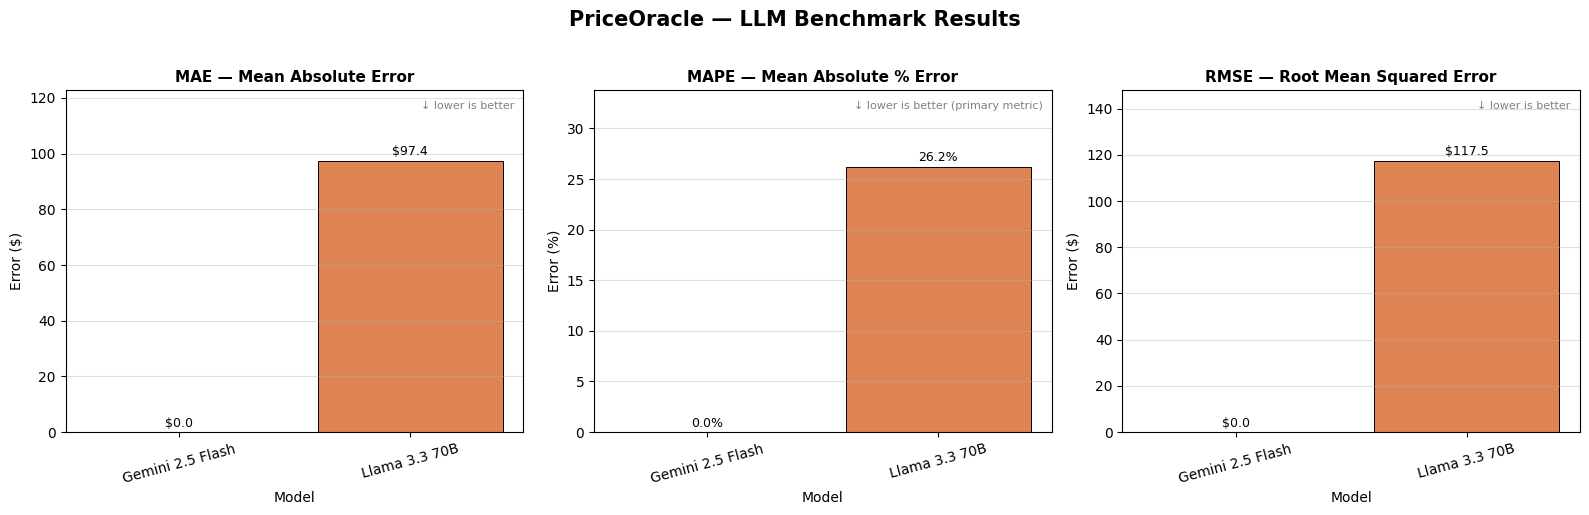

✅ Chart saved as priceorale_benchmark_chart.png


In [ ]:
# ── Cell 11: Visualizations ───────────────────────────────────────

if not model_columns:
    print("⚠️  No data to visualize. Run Cell 9 first.")
else:
    # ── Collect raw metric values for plotting ─────────────────────
    plot_data = []
    for model_name, col in model_columns:
        y_pred = results_df[col].tolist()
        metrics = compute_metrics(y_true, y_pred)
        plot_data.append({
            "model": model_name,
            "MAE":   metrics["MAE"]  if metrics["MAE"]  is not None else 0,
            "MAPE":  metrics["MAPE"] if metrics["MAPE"] is not None else 0,
            "RMSE":  metrics["RMSE"] if metrics["RMSE"] is not None else 0
        })

    plot_df = pd.DataFrame(plot_data)

    # ── Plot ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("PriceOracle — LLM Benchmark Results", fontsize=15, fontweight="bold", y=1.02)

    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

    # Chart 1: MAE
    ax1 = axes[0]
    bars = ax1.bar(plot_df["model"], plot_df["MAE"], color=colors[:len(plot_df)], edgecolor="black", linewidth=0.7)
    ax1.set_title("MAE — Mean Absolute Error", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Error ($)", fontsize=10)
    ax1.set_xlabel("Model", fontsize=10)
    ax1.tick_params(axis='x', rotation=15)
    for bar in bars:
        h = bar.get_height()
        ax1.annotate(f"${h:.1f}", xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)
    ax1.set_ylim(0, max(plot_df["MAE"]) * 1.25 + 1)
    ax1.grid(axis='y', alpha=0.4)
    ax1.annotate("↓ lower is better", xy=(0.98, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8, color='gray')

    # Chart 2: MAPE
    ax2 = axes[1]
    bars = ax2.bar(plot_df["model"], plot_df["MAPE"], color=colors[:len(plot_df)], edgecolor="black", linewidth=0.7)
    ax2.set_title("MAPE — Mean Absolute % Error", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Error (%)", fontsize=10)
    ax2.set_xlabel("Model", fontsize=10)
    ax2.tick_params(axis='x', rotation=15)
    for bar in bars:
        h = bar.get_height()
        ax2.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)
    ax2.set_ylim(0, max(plot_df["MAPE"]) * 1.25 + 1)
    ax2.grid(axis='y', alpha=0.4)
    ax2.annotate("↓ lower is better (primary metric)", xy=(0.98, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8, color='gray')

    # Chart 3: RMSE
    ax3 = axes[2]
    bars = ax3.bar(plot_df["model"], plot_df["RMSE"], color=colors[:len(plot_df)], edgecolor="black", linewidth=0.7)
    ax3.set_title("RMSE — Root Mean Squared Error", fontsize=11, fontweight="bold")
    ax3.set_ylabel("Error ($)", fontsize=10)
    ax3.set_xlabel("Model", fontsize=10)
    ax3.tick_params(axis='x', rotation=15)
    for bar in bars:
        h = bar.get_height()
        ax3.annotate(f"${h:.1f}", xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)
    ax3.set_ylim(0, max(plot_df["RMSE"]) * 1.25 + 1)
    ax3.grid(axis='y', alpha=0.4)
    ax3.annotate("↓ lower is better", xy=(0.98, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8, color='gray')

    plt.tight_layout()
    plt.savefig("priceorale_benchmark_chart.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Chart saved as priceorale_benchmark_chart.png")

## Cell 12 — Per-Product Breakdown Table

Shows ground truth vs. each model's prediction for every product, with the per-product absolute error.

This table helps you identify which product categories each model handles well or poorly.

**Expected output:** A formatted table with all predictions side by side.

In [ ]:
# ── Cell 12: Per-Product Breakdown ────────────────────────────────

if not model_columns:
    print("⚠️  No predictions available. Run Cell 9 first.")
else:
    display_df = results_df[["name", "category", "ground_truth_price"]].copy()

    for model_name, col in model_columns:
        display_df[model_name] = results_df[col].apply(
            lambda x: f"${x:.2f}" if x is not None else "FAILED"
        )
        # Absolute error column
        err_col = model_name.replace(" ", "_") + "_err"
        display_df[err_col] = results_df.apply(
            lambda row: abs(row["ground_truth_price"] - row[col])
                        if row[col] is not None else None,
            axis=1
        ).apply(
            lambda x: f"${x:.2f}" if x is not None else "—"
        )

    # Format ground truth
    display_df["ground_truth_price"] = display_df["ground_truth_price"].apply(lambda x: f"${x:.2f}")

    pd.set_option('display.max_colwidth', 45)
    pd.set_option('display.max_rows', 25)

    print("📋 Per-Product Prediction Breakdown:")
    print("   (err columns show absolute dollar error per product)")
    print()
    print(display_df.to_string(index=False))

📋 Per-Product Prediction Breakdown:
   (err columns show absolute dollar error per product)

                             name   category ground_truth_price Gemini 2.5 Flash Gemini_2.5_Flash_err Llama 3.3 70B Llama_3.3_70B_err
    Sony BRAVIA 55-inch 4K LED TV Television            $748.00           FAILED                    —       $898.00           $150.00
       Samsung 65-inch QLED 4K TV Television           $1097.99           FAILED                    —      $1299.99           $202.00
       LG 43-inch 4K UHD Smart TV Television            $296.99           FAILED                    —       $399.99           $103.00
     TCL 32-inch HD Roku Smart TV Television            $129.99           FAILED                    —       $129.99             $0.00
       Hisense 50-inch 4K ULED TV Television            $329.99           FAILED                    —       $499.99           $170.00
     Apple MacBook Air 13-inch M3     Laptop           $1099.00           FAILED                    —  

## Cell 13 — Save Results to CSV

Saves the full results DataFrame (with all predictions) to a CSV file.

You can download this file from Colab and include it in your project submission.

**To download from Colab:** After running this cell, click the **folder icon** in the left sidebar, find `priceoralce_results.csv`, right-click → Download.

**Expected output:** `✅ Results saved to priceoralce_results.csv`

In [ ]:
# ── Cell 13: Save Results ─────────────────────────────────────────

output_filename = "priceoralce_results.csv"

if not model_columns:
    print("⚠️  No predictions to save. Run Cell 9 first.")
else:
    save_df = results_df.copy()

    # Rename columns for readability
    rename_map = {}
    if "gemini_pred" in save_df.columns:
        rename_map["gemini_pred"] = "Gemini_2.5_Flash_pred"
    if "llama_pred" in save_df.columns:
        rename_map["llama_pred"] = "Llama_3.3_70B_pred"
    if "gpt_pred" in save_df.columns:
        rename_map["gpt_pred"] = "GPT_4o_mini_pred"

    save_df = save_df.rename(columns=rename_map)
    save_df.to_csv(output_filename, index=False)

    print(f"✅ Results saved to {output_filename}")
    print(f"   Rows: {len(save_df)}, Columns: {list(save_df.columns)}")
    print()
    print("📥 To download from Colab:")
    print("   1. Click the folder icon in the left sidebar")
    print("   2. Find 'priceoralce_results.csv'")
    print("   3. Right-click → Download")
    print()

    # Also save the leaderboard
    leaderboard_rows_raw = []
    for model_name, col in model_columns:
        y_pred = results_df[col].tolist()
        metrics = compute_metrics(y_true, y_pred)
        leaderboard_rows_raw.append({
            "Model":       model_name,
            "MAE_dollar":  metrics["MAE"],
            "MAPE_pct":    metrics["MAPE"],
            "RMSE_dollar": metrics["RMSE"],
            "Coverage_pct": metrics["coverage"]
        })

    leaderboard_save_df = pd.DataFrame(leaderboard_rows_raw)
    leaderboard_save_df = leaderboard_save_df.sort_values("MAPE_pct", ascending=True)
    leaderboard_save_df.to_csv("priceoralce_leaderboard.csv", index=False)
    print("✅ Leaderboard saved to priceoralce_leaderboard.csv")

---

## ✅ Project Complete!

### What You Built

**PriceOracle** is a fully functional multi-LLM benchmarking system that:
- Evaluates 2–3 state-of-the-art LLMs on real product price prediction
- Uses structured JSON prompting for reliable output parsing
- Computes MAE, MAPE, and RMSE evaluation metrics
- Displays a ranked leaderboard and visualizations
- Handles API failures gracefully with retry logic

### Files Generated

| File | Description |
|------|-------------|
| `priceoralce_results.csv` | Full predictions table |
| `priceoralce_leaderboard.csv` | Metric summary per model |
| `priceoralce_benchmark_chart.png` | Bar chart visualization |

### Key Concepts Demonstrated

- **Structured output prompting** — JSON format enforcement across different LLM providers
- **Robust response parsing** — multi-layer fallback strategy (JSON → regex → None)
- **Evaluation metrics** — MAE, MAPE, RMSE with coverage tracking
- **API integration** — Gemini, Groq, and OpenAI with unified interface
- **Rate limit handling** — exponential backoff retry logic
- **Multi-model comparison** — leaderboard ranking with visual output

---

*PriceOracle | LLM Evaluation Sprint | Days 41-45*